/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  Price  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  
             CRIM          ZN       INDUS         NOX          RM         AGE  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.554695    6.284634   68.574901   
std      8.601545   23.322453    6.860353    0.115878    0.702617   28.148861   
min      0.006320    0.000000    0.4600

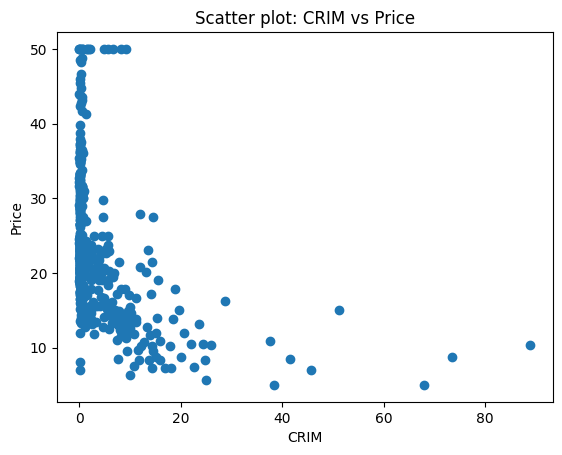

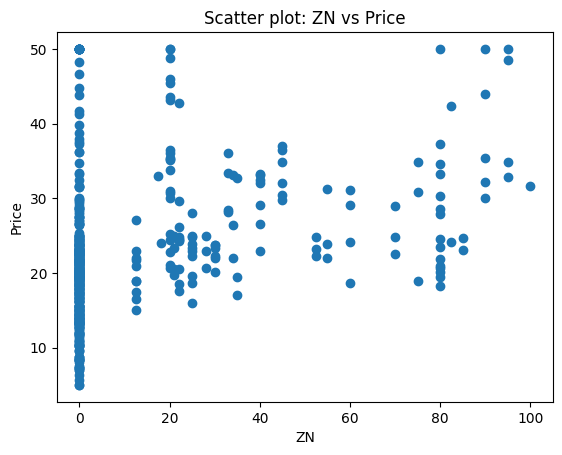

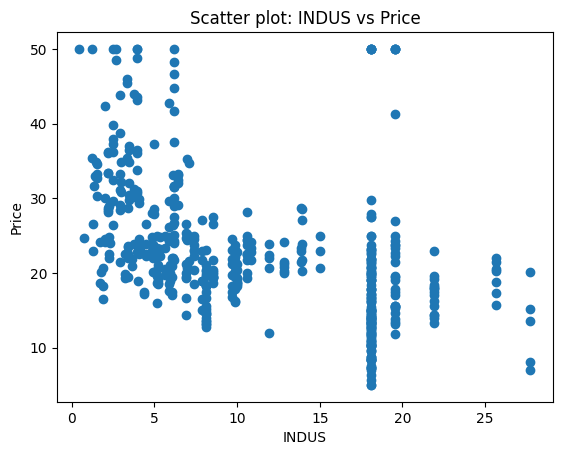

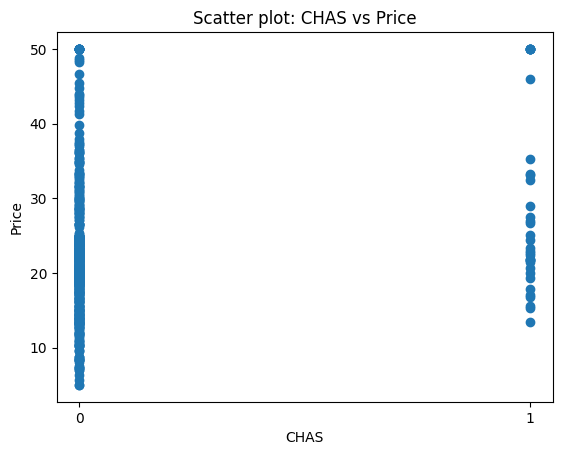

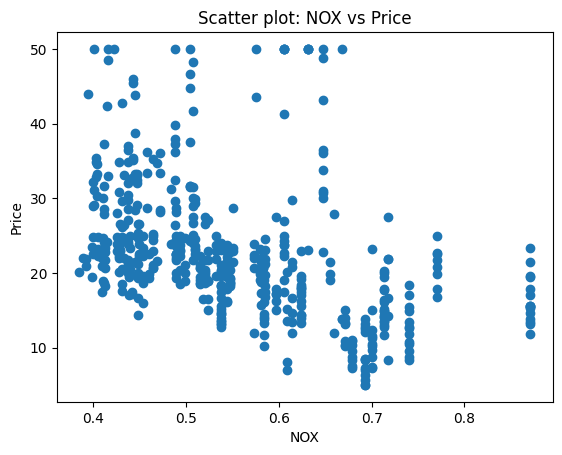

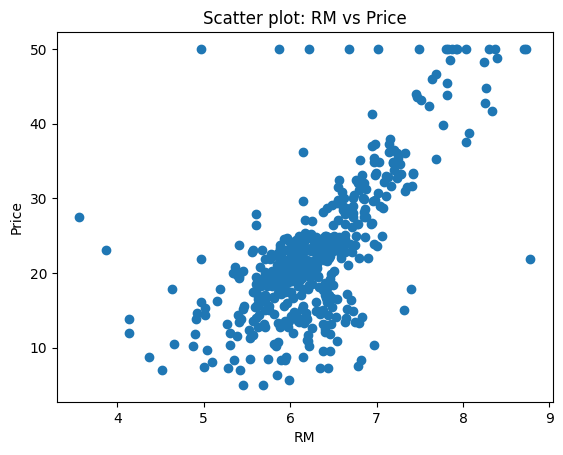

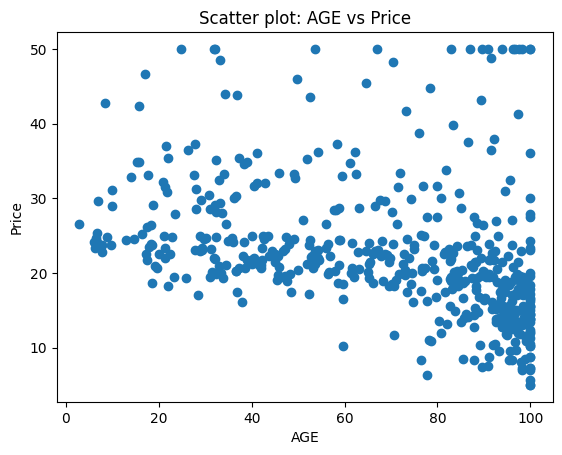

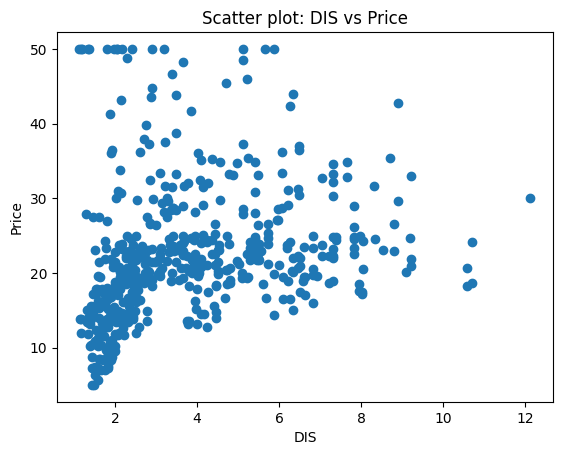

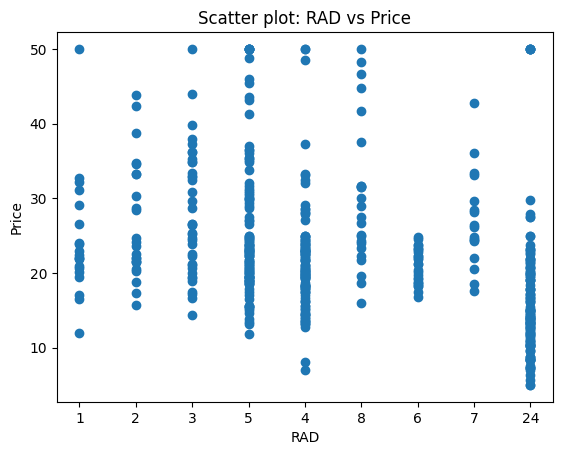

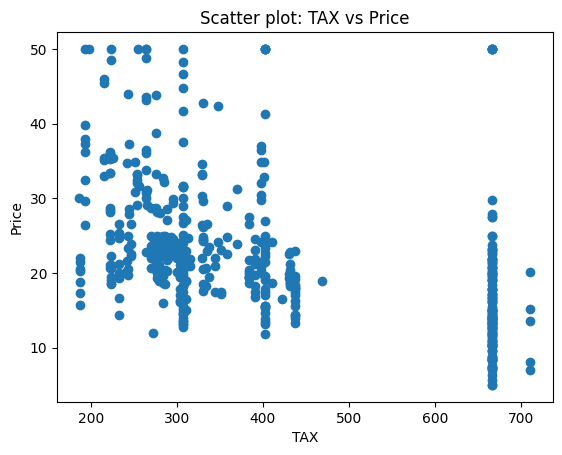

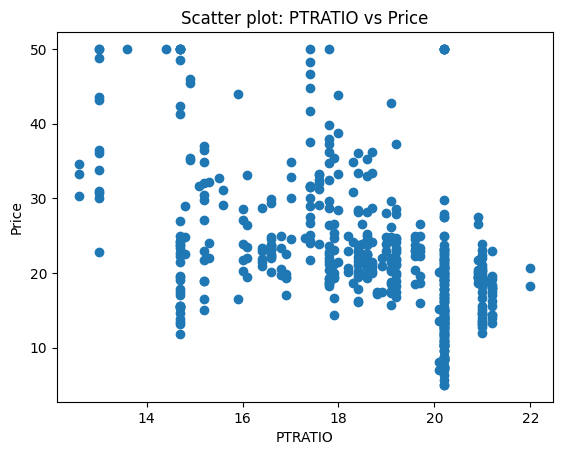

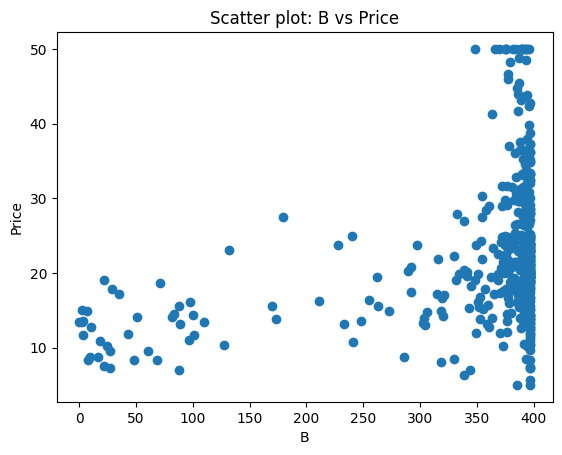

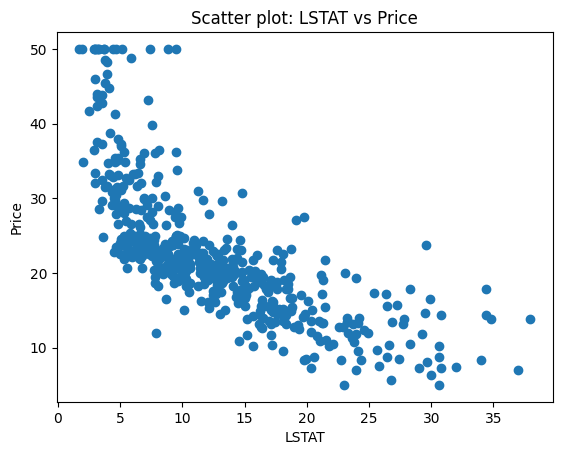

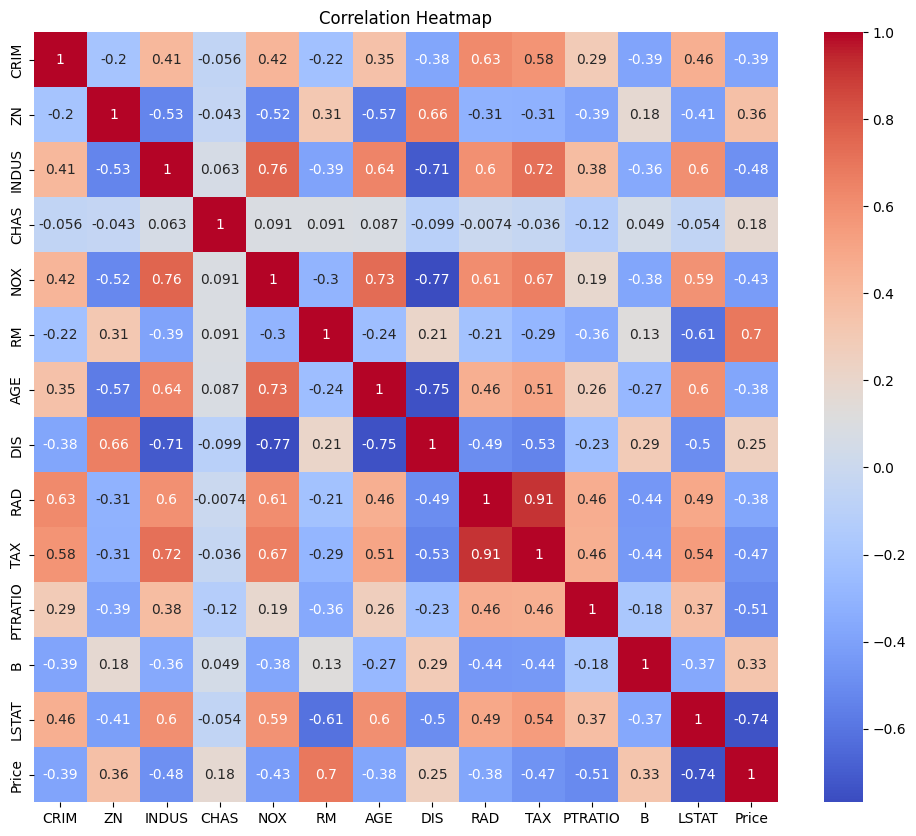

Optimized model parameters: [ 2.60855371e-05 -1.19095672e-01  1.91428917e-01  3.96598258e-02
  6.98822378e-02 -1.71236783e-01  3.38518102e-01 -1.13225064e-01
 -4.47259237e-01  3.88758058e-01 -4.08488023e-01 -1.70473348e-01
  1.05219370e-01 -3.15043587e-01]
Mean Absolute Error: 0.36588746627766083
Mean Squared Error: 0.2721106379361004
Scikit-Learn MAE: 0.35599245764783993
Scikit-Learn MSE: 0.2593573358905906


In [5]:
# Install necessary libraries
!pip install numpy pandas matplotlib scikit-learn seaborn

# Import libraries for data manipulation and visualization
import numpy as np  # Numerical operations
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Statistical data visualization
from sklearn.datasets import fetch_openml  # Fetch datasets from OpenML
from sklearn.preprocessing import StandardScaler  # Feature scaling
from sklearn.linear_model import LinearRegression  # Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Model evaluation metrics

# 1. Data Loading and Exploration
# Load the Boston Housing Dataset
boston_data = fetch_openml(name='boston', version=1)  # Fetch the dataset from OpenML
boston_df = pd.DataFrame(boston_data.data, columns=boston_data.feature_names)  # Convert dataset to DataFrame
boston_df['Price'] = boston_data.target  # Add target variable as a new column

# Display the first few rows of the dataset
print(boston_df.head())  # Show the first 5 rows of the DataFrame

# Describe the dataset using statistical summaries
print(boston_df.describe())  # Display summary statistics of the dataset

# 2. Data Preprocessing
# Check for missing values
print(boston_df.isnull().sum())  # Display the count of missing values in each column

# Normalize the dataset if necessary
scaler = StandardScaler()  # Initialize the StandardScaler
boston_df_normalized = pd.DataFrame(scaler.fit_transform(boston_df), columns=boston_df.columns)  # Scale features and create new DataFrame

# Display the first few rows of the scaled dataset
print(boston_df_normalized.head())  # Show the first 5 rows of the scaled DataFrame

# 3. Data Visualization
# Scatter plots to visualize the relationship between each feature and the target variable
for feature in boston_df.columns[:-1]:  # Iterate over all feature columns
    plt.scatter(boston_df[feature], boston_df['Price'])  # Create scatter plot for the current feature vs Price
    plt.xlabel(feature)  # Label x-axis
    plt.ylabel('Price')  # Label y-axis
    plt.title(f'Scatter plot: {feature} vs Price')  # Set the title of the plot
    plt.show()  # Display the plot

# Correlation heatmap
plt.figure(figsize=(12, 10))  # Set the figure size for the heatmap
sns.heatmap(boston_df.corr(), annot=True, cmap='coolwarm')  # Create heatmap for feature correlations
plt.title('Correlation Heatmap')  # Set the title of the heatmap
plt.show()  # Display the heatmap

# 4. Formulating the Optimization Problem
# Define the cost function (Mean Squared Error)
def compute_cost(X, y, model_parameters):  # Function to compute cost
    m = len(y)  # Number of training examples
    predictions = X.dot(model_parameters)  # Compute predictions
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))  # Calculate cost
    return cost  # Return the cost

# 5. Implementation of Linear Regression with Hill Climbing Optimization
# Adding a column of ones to include the intercept term
boston_df_normalized.insert(0, 'Intercept', 1)  # Insert column of ones as intercept term

# Splitting the data into features and target
X = boston_df_normalized.drop('Price', axis=1).values  # Features matrix
y = boston_df_normalized['Price'].values  # Target vector

# Initialize model parameters
model_parameters_initial = np.random.randn(X.shape[1])  # Random initialization of parameters

# Define the Hill Climbing algorithm
def hill_climbing_optimization(X, y, model_parameters, alpha=0.01, iterations=1000):  # Function to optimize model_parameters
    m = len(y)  # Number of training examples
    for i in range(iterations):  # Iterate for a number of iterations
        gradients = X.T.dot(X.dot(model_parameters) - y) / m  # Compute gradients
        model_parameters -= alpha * gradients  # Update parameters
    return model_parameters  # Return the optimized parameters

# Train the model
model_parameters_optimized = hill_climbing_optimization(X, y, model_parameters_initial)  # Optimize model_parameters
print(f'Optimized model parameters: {model_parameters_optimized}')  # Display the optimized parameters

# 6. Evaluation
# Predictions
y_pred = X.dot(model_parameters_optimized)  # Compute predictions using the optimized parameters

# Mean Absolute Error
mae = mean_absolute_error(y, y_pred)  # Calculate Mean Absolute Error
print(f'Mean Absolute Error: {mae}')  # Display MAE

# Mean Squared Error
mse = mean_squared_error(y, y_pred)  # Calculate Mean Squared Error
print(f'Mean Squared Error: {mse}')  # Display MSE

# 7. Comparison with Scikit-Learn
# Implement linear regression using scikit-learn
lin_reg_model = LinearRegression()  # Initialize Linear Regression model
lin_reg_model.fit(X, y)  # Train the model
sklearn_y_pred = lin_reg_model.predict(X)  # Make predictions using scikit-learn model

# Compare the results
sklearn_mae = mean_absolute_error(y, sklearn_y_pred)  # Calculate MAE for scikit-learn model
sklearn_mse = mean_squared_error(y, sklearn_y_pred)  # Calculate MSE for scikit-learn model

print(f'Scikit-Learn MAE: {sklearn_mae}')  # Display MAE for scikit-learn model
print(f'Scikit-Learn MSE: {sklearn_mse}')  # Display MSE for scikit-learn model
